In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

In [ ]:
data = pd.read_csv('/content/Global YouTube Statistics.csv', encoding='windows-1252')

* rank: Position of the YouTube channel based on the number of subscribers
* Youtuber: Name of the YouTube channel
* subscribers: Number of subscribers to the channel
* video views: Total views across all videos on the channel
* category: Category or niche of the channel
* Title: Title of the YouTube channel
* uploads: Total number of videos uploaded on the channel
* Country: Country where the YouTube channel originates
* Abbreviation: Abbreviation of the country
* channel_type: Type of the YouTube channel (e.g., individual, brand)
* video_views_rank: Ranking of the channel based on total video views
* country_rank: Ranking of the channel based on the number of subscribers within its country
* channel_type_rank: Ranking of the channel based on its type (individual or brand)
* video_views_for_the_last_30_days: Total video views in the last 30 days
* lowest_monthly_earnings: Lowest estimated monthly earnings from the channel
* highest_monthly_earnings: Highest estimated monthly earnings from the channel
* lowest_yearly_earnings: Lowest estimated yearly earnings from the channel
* highest_yearly_earnings: Highest estimated yearly earnings from the channel
* subscribers_for_last_30_days: Number of new subscribers gained in the last 30 days
* created_year: Year when the YouTube channel was created
* created_month: Month when the YouTube channel was created
* created_date: Exact date of the YouTube channel’s creation
* Gross tertiary education enrollment (%): Percentage of the population enrolled in tertiary education in the country
* Population: Total population of the country
* Unemployment rate: Unemployment rate in the country
* Urban_population: Percentage of the population living in urban areas
* Latitude: Latitude coordinate of the country’s location
* Longitude: Longitude coordinate of the country’s location

*   Новый пункт
*   Новый пункт



In [ ]:
data.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


# EDA

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                         994 non-n

In [ ]:
data.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00000,9.950000e+02,9.950000e+02,995.000000,9.940000e+02,879.000000,962.000000,9.390000e+02,995.000000,9.950000e+02,...,9.950000e+02,6.580000e+02,990.000000,990.000000,872.000000,8.720000e+02,872.000000,8.720000e+02,872.000000,872.000000
mean,498.00000,2.298241e+07,1.103954e+10,9187.125628,5.542489e+05,386.053470,745.719335,1.756103e+08,36886.148281,5.898078e+05,...,7.081814e+06,3.490791e+05,2012.630303,15.746465,63.627752,4.303873e+08,9.279278,2.242150e+08,26.632783,-14.128146
std,287.37606,1.752611e+07,1.411084e+10,34151.352254,1.362782e+06,1232.244746,1944.386561,4.163782e+08,71858.724092,1.148622e+06,...,1.379704e+07,6.143554e+05,4.512503,8.777520,26.106893,4.727947e+08,4.888354,1.546874e+08,20.560533,84.760809
min,1.00000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,249.50000,1.450000e+07,4.288145e+09,194.500000,3.230000e+02,11.000000,27.000000,2.013750e+07,2700.000000,4.350000e+04,...,5.217500e+05,1.000000e+05,2009.000000,8.000000,36.300000,8.335541e+07,5.270000,5.590832e+07,20.593684,-95.712891
50%,498.00000,1.770000e+07,7.760820e+09,729.000000,9.155000e+02,51.000000,65.500000,6.408500e+07,13300.000000,2.127000e+05,...,2.600000e+06,2.000000e+05,2013.000000,16.000000,68.000000,3.282395e+08,9.365000,2.706630e+08,37.090240,-51.925280
75%,746.50000,2.460000e+07,1.355470e+10,2667.500000,3.584500e+03,123.000000,139.750000,1.688265e+08,37900.000000,6.068000e+05,...,7.300000e+06,4.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.00000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.000000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


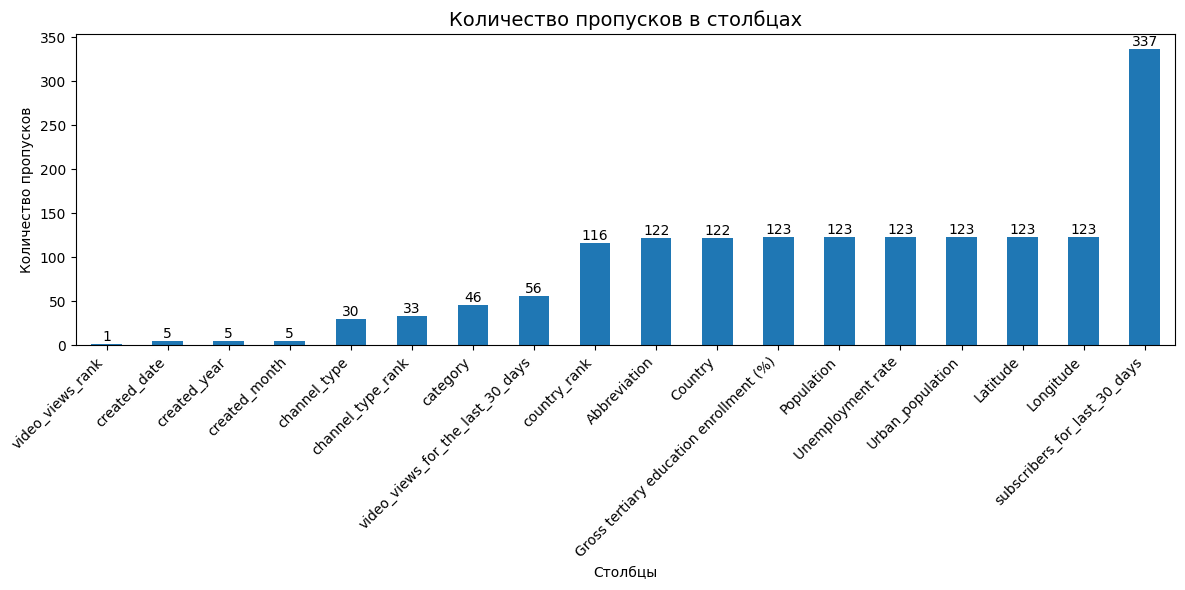

In [ ]:
# Посчитаем пропуски
missing_stats = data.isnull().sum().sort_values()

plt.figure(figsize=(12, 6))
ax = missing_stats[missing_stats > 0].plot(kind='bar')
plt.title('Количество пропусков в столбцах', fontsize=14)
plt.xlabel('Столбцы', fontsize=10)
plt.ylabel('Количество пропусков', fontsize=10)
plt.xticks(rotation=45, ha='right')

# Добавляем значения над каждым столбцом
for i, v in enumerate(missing_stats[missing_stats > 0]):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

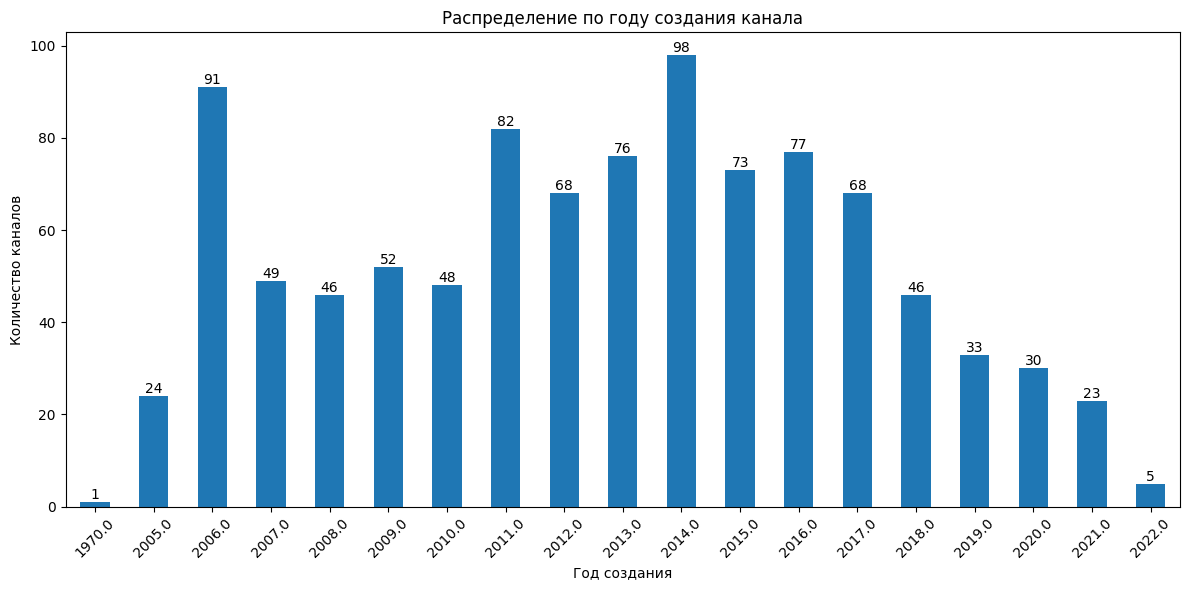

In [ ]:
# Оценим в каком году сколько каналов было зараегистрировано
plt.figure(figsize=(12, 6))
ax = data['created_year'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение по году создания канала')
plt.xlabel('Год создания')
plt.ylabel('Количество каналов')
plt.xticks(rotation=45)

# Добавляем значения над каждым столбцом
for i, v in enumerate(data['created_year'].value_counts().sort_index()):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

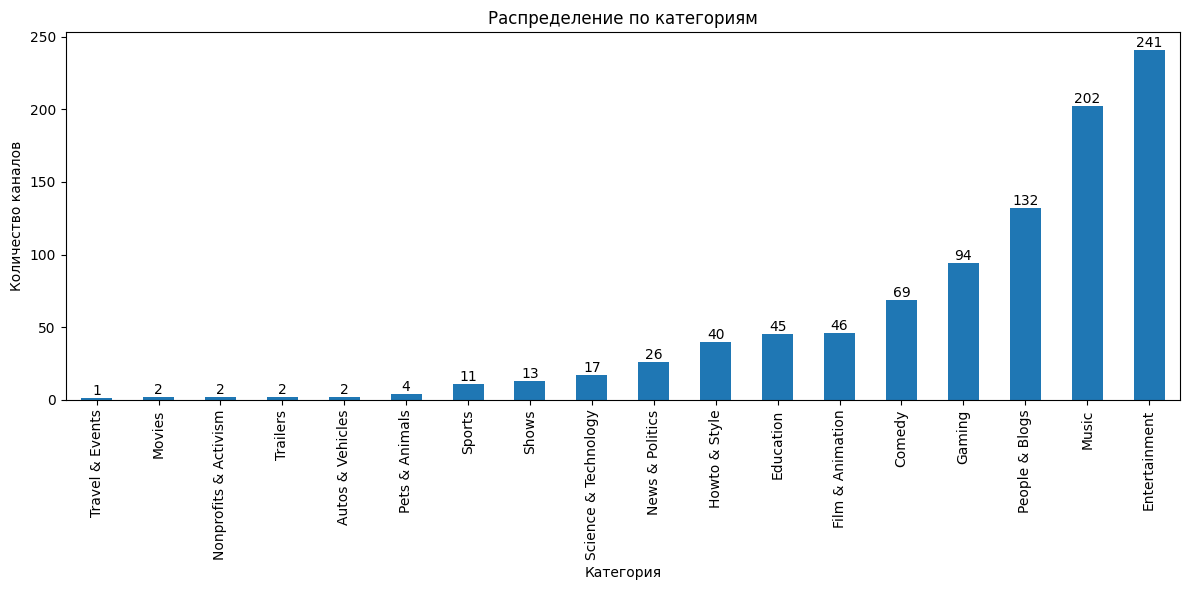

In [ ]:
# Распределение каналов по категориям
plt.figure(figsize=(12, 6))
ax = data['category'].value_counts().sort_values().plot(kind='bar')
plt.title('Распределение по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество каналов')
plt.xticks(rotation=90)

# Добавляем значения над каждым столбцом
for i, v in enumerate(data['category'].value_counts().sort_values()):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

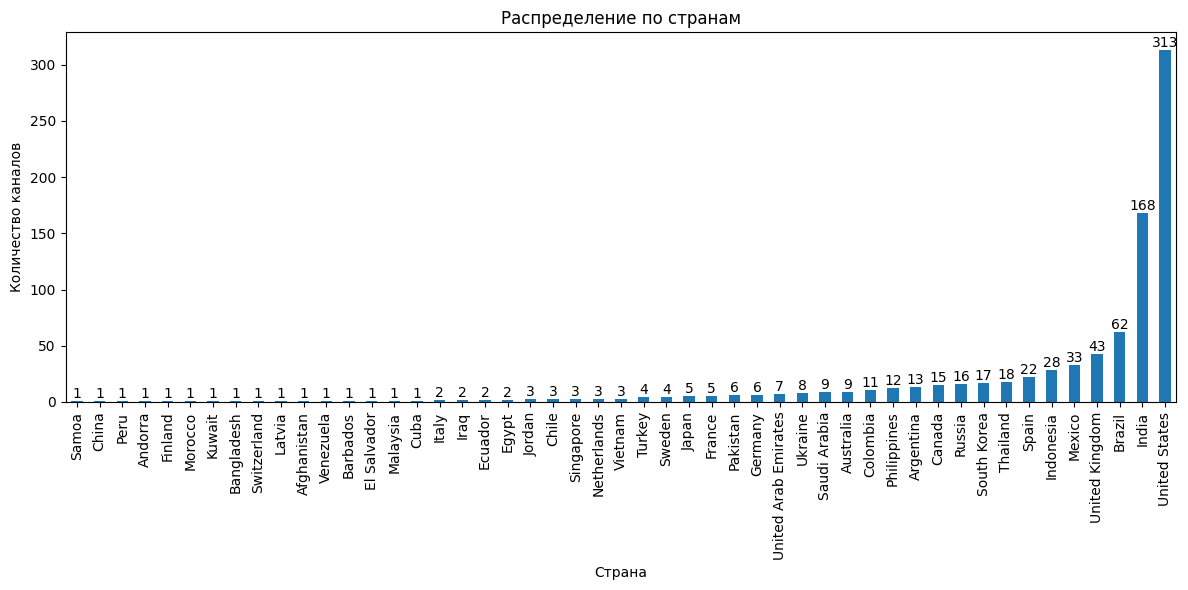

In [ ]:
# Распределение каналов по странам
plt.figure(figsize=(12, 6))
ax = data['Country'].value_counts().sort_values().plot(kind='bar')
plt.title('Распределение по странам')
plt.xlabel('Страна')
plt.ylabel('Количество каналов')
plt.xticks(rotation=90)

# Добавляем значения над каждым столбцом
for i, v in enumerate(data['Country'].value_counts().sort_values()):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

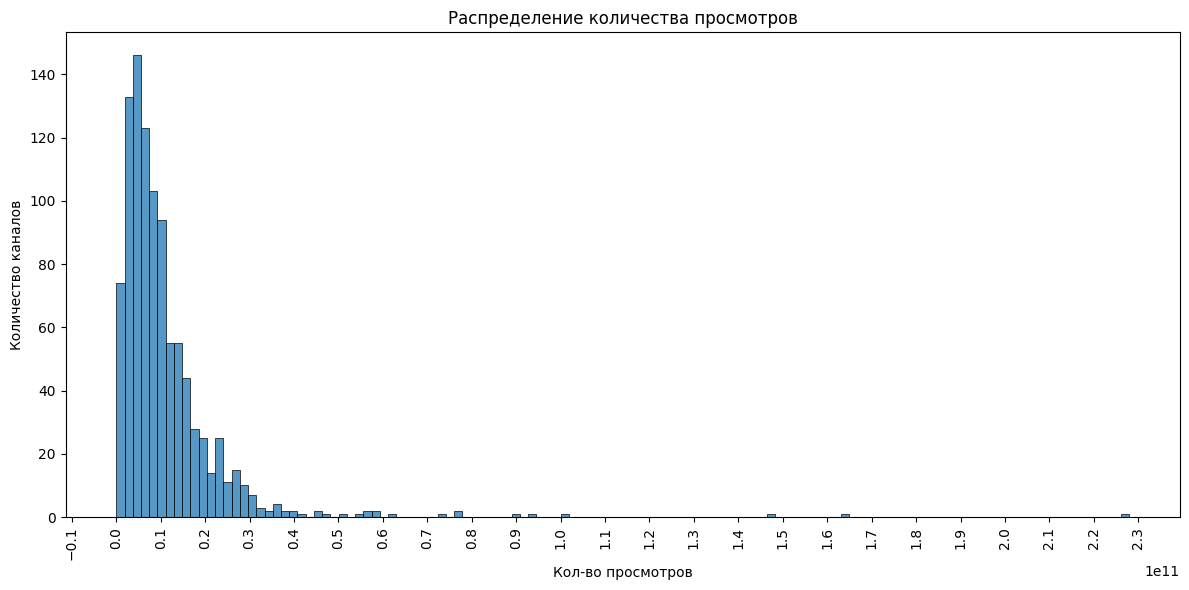

In [ ]:
# Оценим распрделение числа загруженных на канал видео
plt.figure(figsize=(12, 6))
ax = sns.histplot(data['video views'])
plt.title('Распределение количества просмотров')
plt.xlabel('Кол-во просмотров')
plt.ylabel('Количество каналов')
plt.xticks(rotation=90)
plt.locator_params(axis='x', nbins=50)

plt.tight_layout()
plt.show()

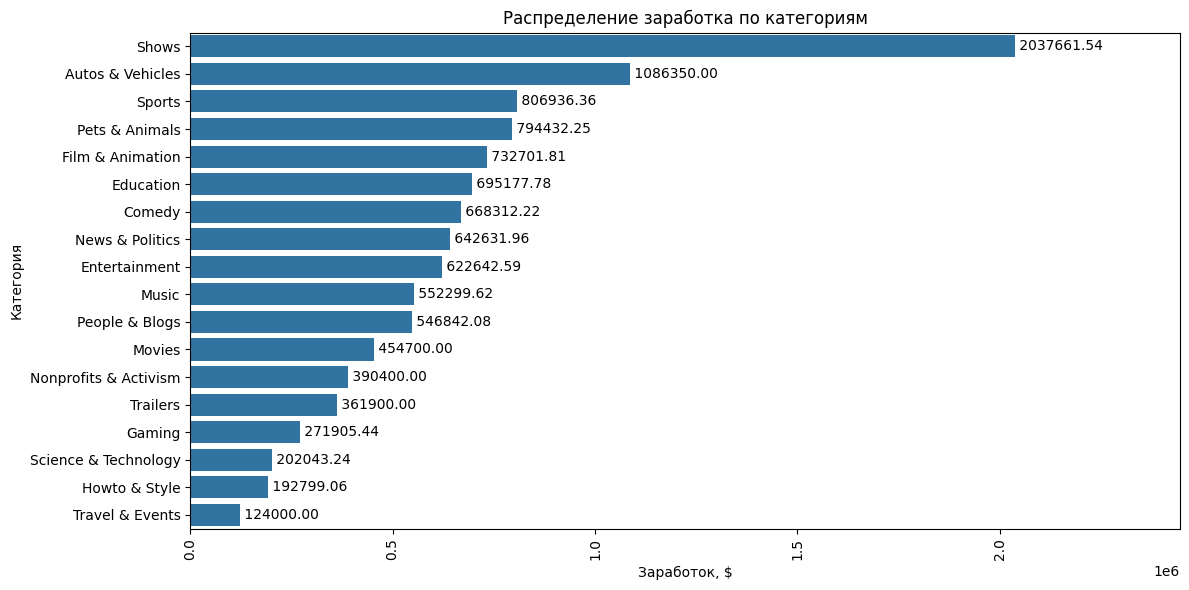

In [ ]:
# Распределение заработка по категориям
plt.figure(figsize=(12, 6))
data_grouped = data.groupby(by='category')['highest_monthly_earnings'].mean().sort_values(ascending=False)
ax = sns.barplot(data_grouped, orient='h')
plt.title('Распределение заработка по категориям')
plt.ylabel('Категория')
plt.xlabel('Заработок, $')
plt.xticks(rotation=90)

# Добавление значений справа от баров
for i, v in enumerate(data_grouped.values):
    ax.text(v, i, f' {v:.2f}', va='center')

# Расширяем область графика справа
plt.xlim(0, data_grouped.max() * 1.2)

plt.tight_layout()
plt.show()

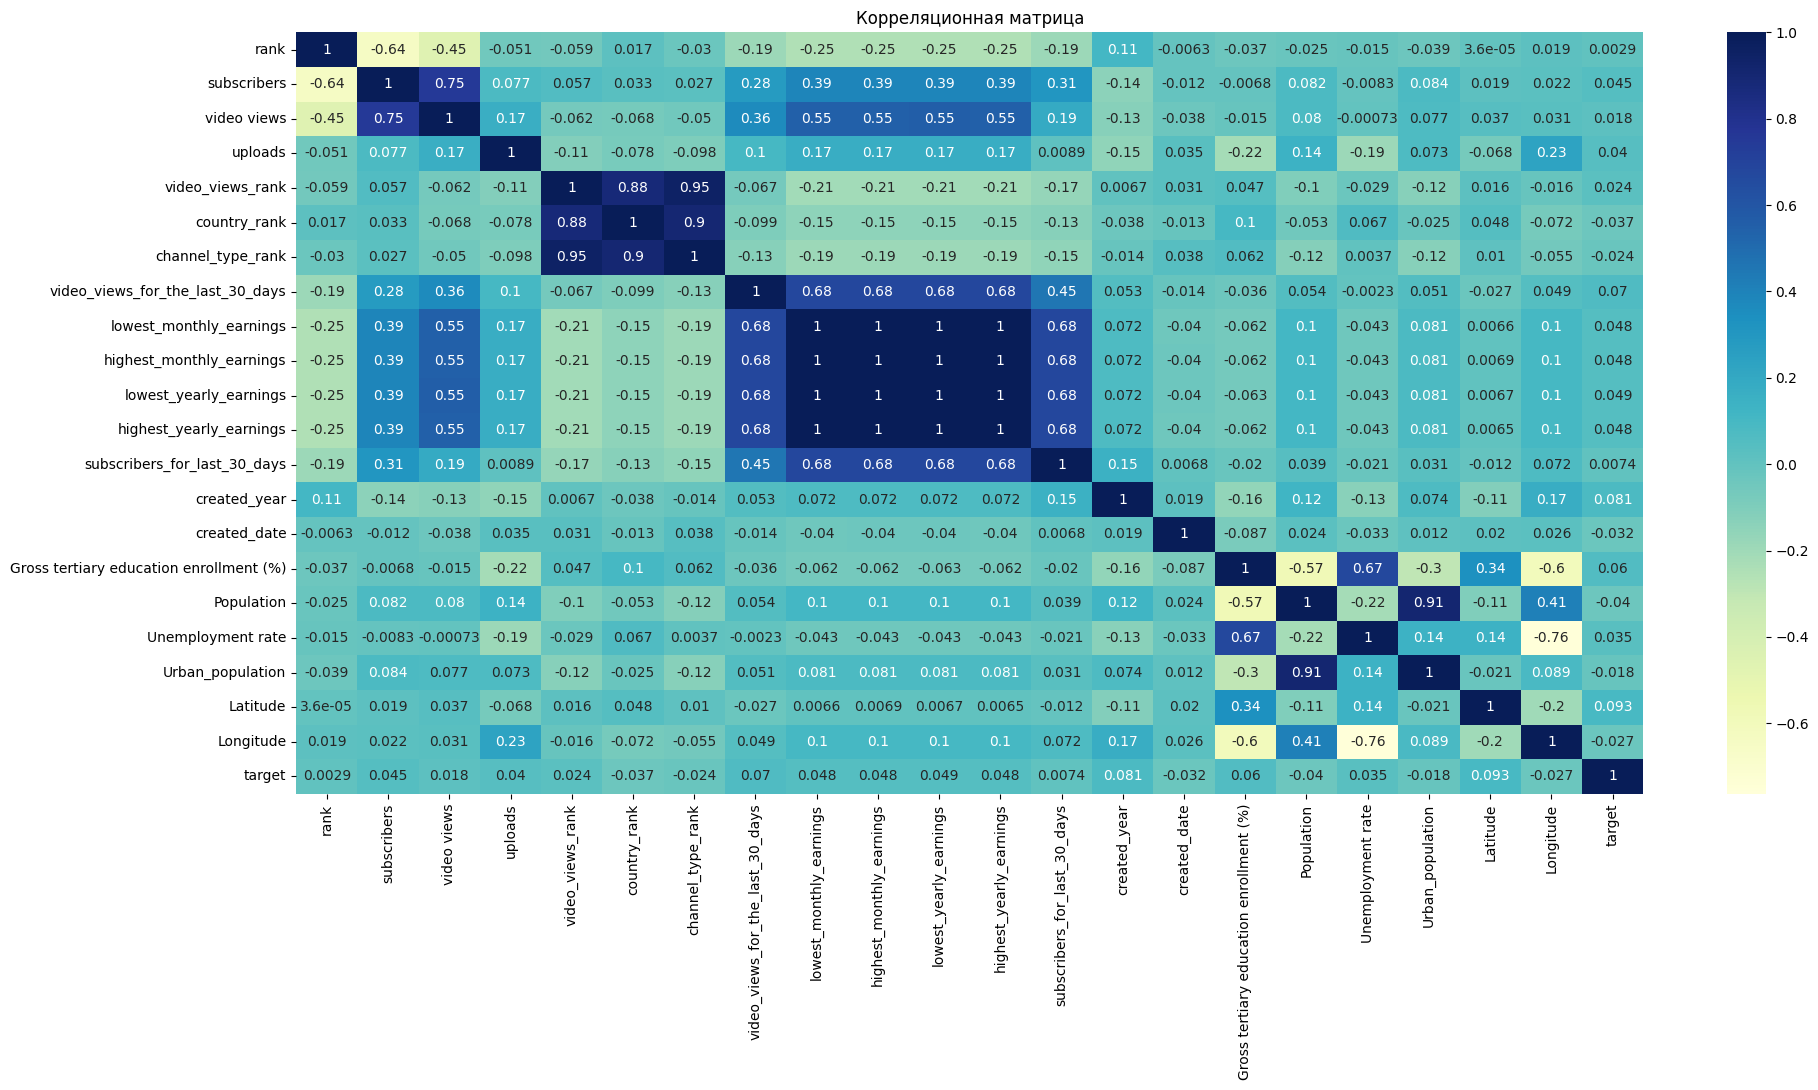

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Применение к данным
data['target'] = encoder.fit_transform(data['category'])

# Корреляционная матрица
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(20, 11))
sns.heatmap(corr_matrix, cmap="YlGnBu", annot=True)

plt.title('Корреляционная матрица')
plt.tight_layout()

plt.show()

# Задание 2. Корреляционный анализ

* Оставьте два коррелирующих столбца: "subscribers" и"video views".
* Отфильтруйте данные - уберите те строки, где кол-во просмотров равно нулю.
* Рассчитайте коэффициент корреляции Пирсона.
* Определите "video views" как признак Х, а "subscribers" - как целевую переменную.
* Разделите выборку на тестовую и тренировочную.
* Постройте модель линейной регрессии.
* Рассчитайте точность модели на тестовой выборке.
* Как изменится точность, если опустить пункт 2 и не убирать из данных нулевые просмотры?

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [ ]:
data_cut = data.loc[:, ["subscribers", "video views"]]
data_cut_filtered = data_cut.loc[(data_cut['subscribers'] > 0) & (data_cut['video views'] > 0)]

In [ ]:
corr_coef = data_cut['subscribers'].corr(data_cut['video views'])
print('Коэфифциент корреляции Пиросона = ', corr_coef)

Коэфифциент корреляции Пиросона =  0.7509576173780216


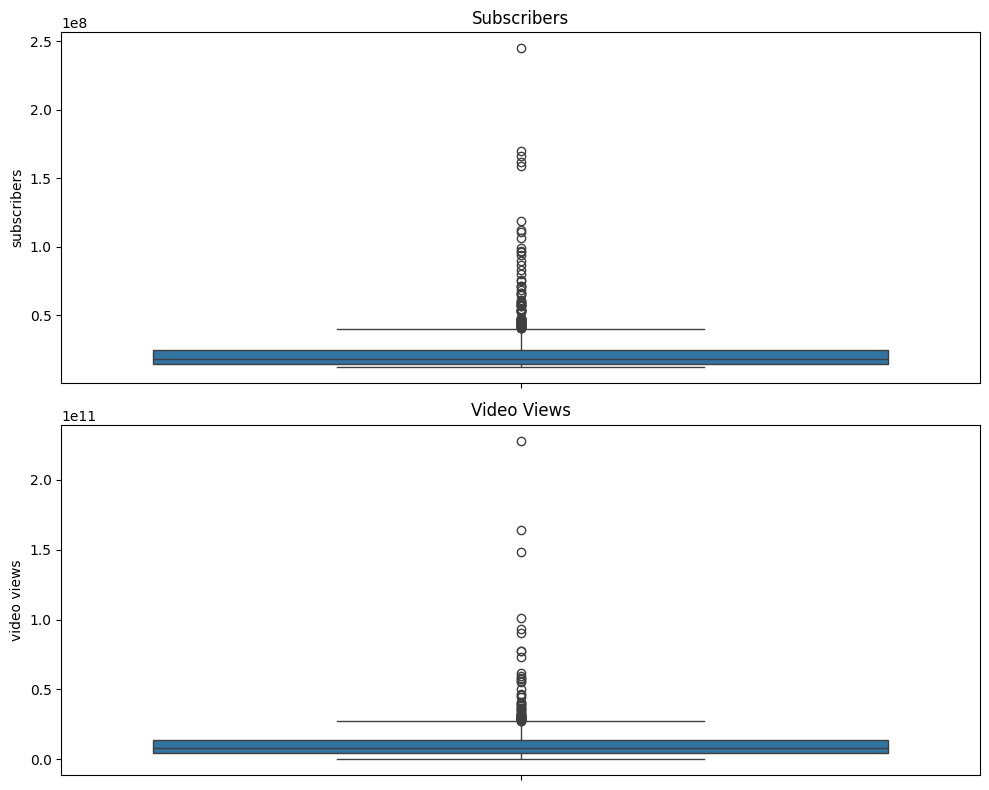

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Боксплот для subscribers
sns.boxplot(data=data_cut['subscribers'], ax=axes[0])
axes[0].set_title('Subscribers')

# Боксплот для video views
sns.boxplot(data=data_cut['video views'], ax=axes[1])
axes[1].set_title('Video Views')

plt.tight_layout()
plt.show()

Данные имеют много выбросов

## Модели на очищенных данных

In [ ]:
def remove_outliers(df : pd.DataFrame) -> pd.DataFrame:
  """
  Позволяет удалить выбросы в некатегориальных столбцах переданного датафрейма
  :param df - датафрейм с данными
  """
  cleaned_df = df.copy()
  # Проходим по всем числовым столбцам
  for column in cleaned_df.select_dtypes(include=['float64', 'int64']).columns:
      # Вычисляем первый (Q1) и третий (Q3) квартиль
      Q1 = cleaned_df[column].quantile(0.25)
      Q3 = cleaned_df[column].quantile(0.75)

      # Вычисляем межквартильный размах (IQR)
      IQR = Q3 - Q1

      # Определяем границы для выбросов
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR

      # Удаляем выбросы
      cleaned_df = cleaned_df[(cleaned_df[column] >= lower_bound) & (cleaned_df[column] <= upper_bound)]

  return cleaned_df

In [ ]:
clean_data = remove_outliers(data_cut)
clean_filtered_data = remove_outliers(data_cut_filtered)

r2 для модели построенной на отфильтрованных очищенных данных =  0.18283674575564665


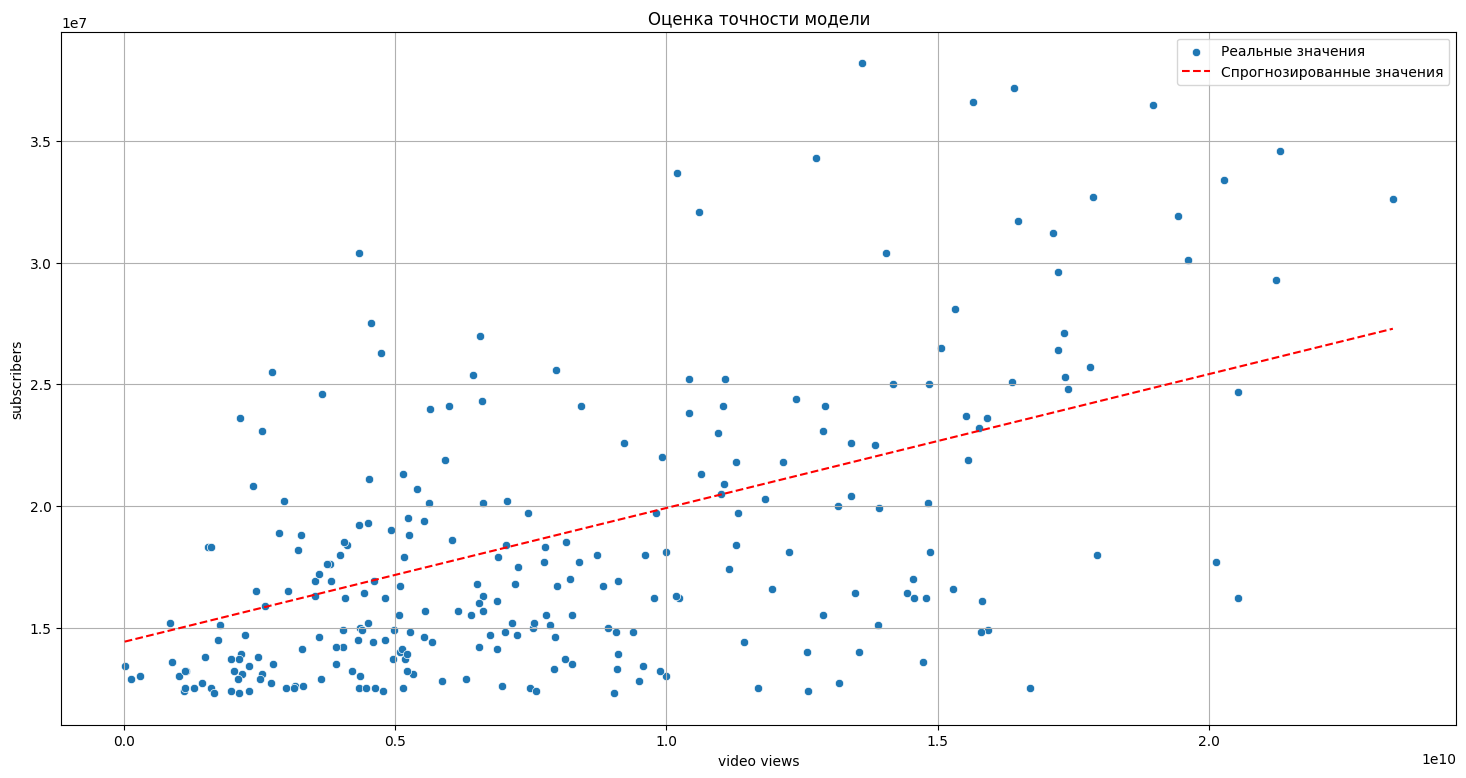

In [ ]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(clean_filtered_data['video views'].values.reshape(-1, 1)
                                                    , clean_filtered_data['subscribers'], test_size=0.3, random_state=5)

#  Модель на отфильтрованных данных
model_filtered = LinearRegression()
model_filtered.fit(X_train_f, y_train_f)

# Предсказание на тестовых данных
y_pred = model_filtered.predict(X_test_f)

# Сохранение десяти метрик в переменной r2
r2_clean_filter = cross_val_score(model_filtered,
                      X_test_f,
                      y_test_f,
                      scoring='r2',
                      cv=10)

# Получение среднего значения для оценки качества модели
print('r2 для модели построенной на отфильтрованных очищенных данных = ', r2_clean_filter.mean())

# Визуализация адекватности модели
plt.figure(figsize=(18, 9))
sns.scatterplot(x=X_test_f[:, 0] , y=y_test_f, label='Реальные значения')
sns.lineplot(x=X_test_f[:, 0] , y=y_pred, label='Спрогнозированные значения', color='red', linestyle='--')
plt.xlabel('video views')
plt.grid(True)
plt.legend()
plt.title('Оценка точности модели')
plt.show()

r2 для модели построенной на неотфильтрованных очищенных данных =  0.17385926340870142


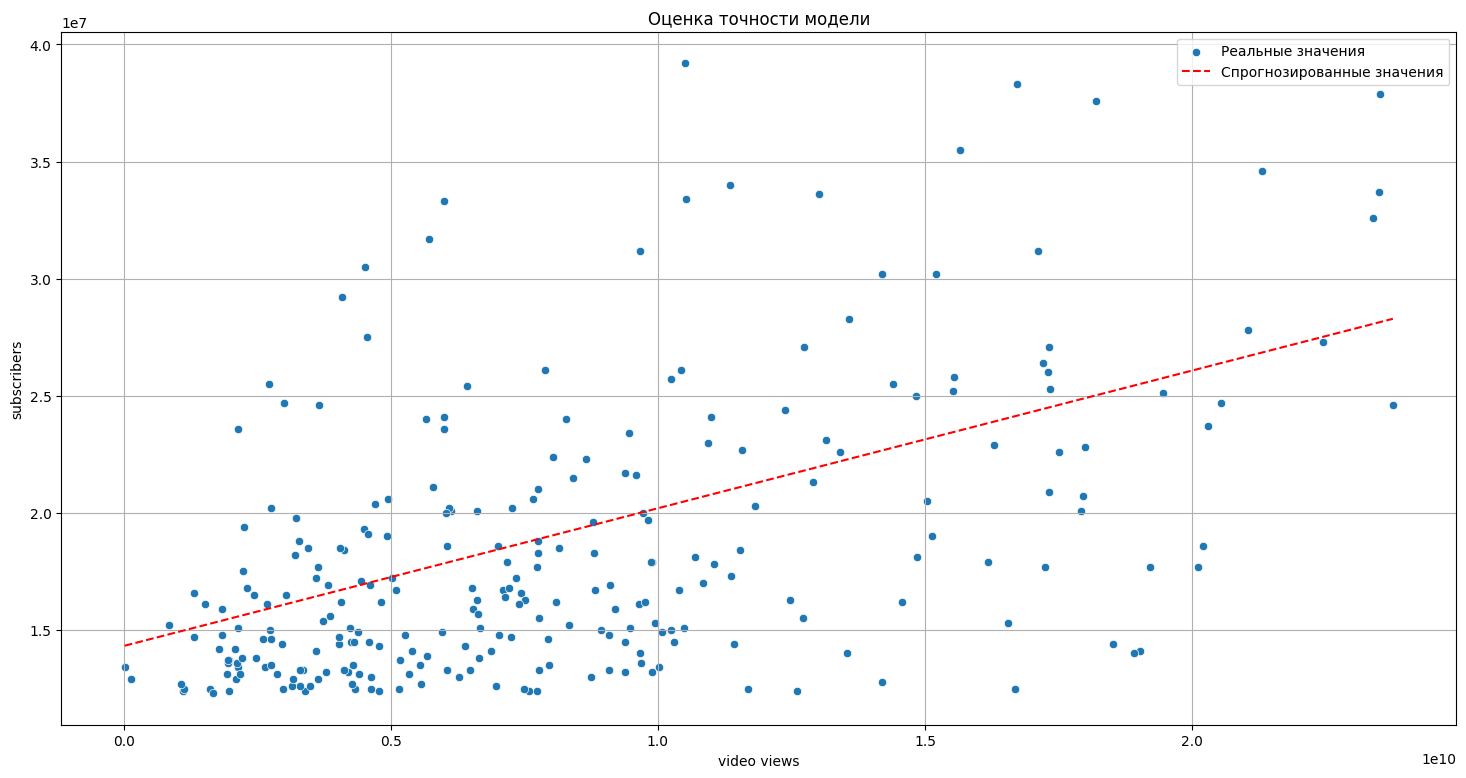

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(clean_data['video views'].values.reshape(-1, 1)
                                                    , clean_data['subscribers'], test_size=0.3, random_state=5)

# Модель на неотфильтрованных данных
model = LinearRegression()
model.fit(X_train, y_train)

# Модель на неотфильтрованных данных
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказание на тестовых данных
y_pred = model.predict(X_test)

# Сохранение десяти метрик в переменной r2
r2_clean_unfiltered = cross_val_score(model,
                      X_test,
                      y_test,
                      scoring='r2',
                      cv=10)

# Получение среднего значения для оценки качества модели
print('r2 для модели построенной на неотфильтрованных очищенных данных = ', r2_clean_unfiltered.mean())

# Визуализация адекватности модели
plt.figure(figsize=(18, 9))
sns.scatterplot(x=X_test[:, 0] , y=y_test, label='Реальные значения')
sns.lineplot(x=X_test[:, 0] , y=y_pred, label='Спрогнозированные значения', color='red', linestyle='--')
plt.xlabel('video views')
plt.grid(True)
plt.legend()
plt.title('Оценка точности модели')
plt.show()

## Модели на неочищенных данных

r2 для модели построенной на отфильтрованных неочищенных данных =  0.4445840147517116


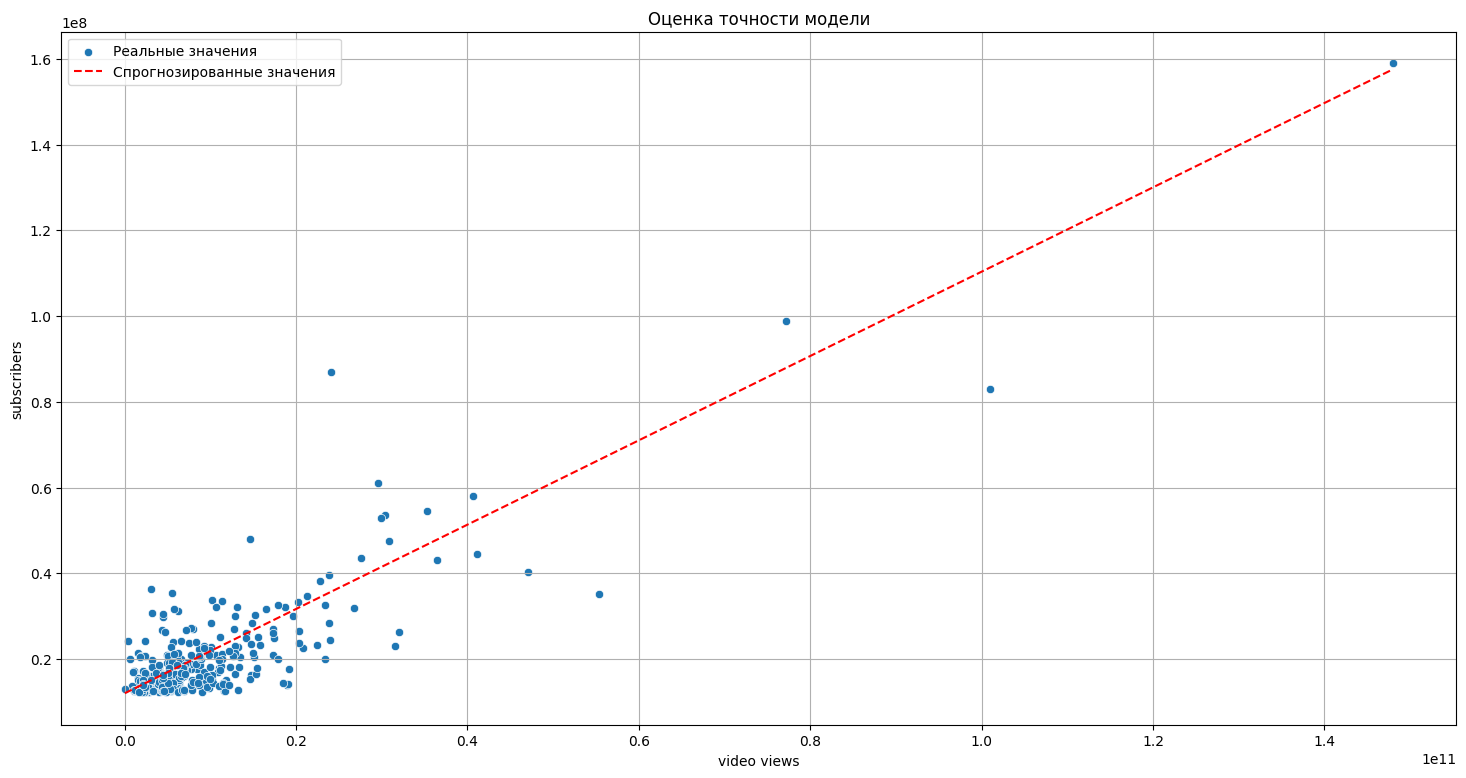

In [ ]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(data_cut_filtered['video views'].values.reshape(-1, 1)
                                                    , data_cut_filtered['subscribers'], test_size=0.3, random_state=5)

#  Модель на отфильтрованных данных
model_filtered = LinearRegression()
model_filtered.fit(X_train_f, y_train_f)

# Предсказание на тестовых данных
y_pred = model_filtered.predict(X_test_f)

# Сохранение десяти метрик в переменной r2
r2_filtered = cross_val_score(model_filtered,
                      X_test_f,
                      y_test_f,
                      scoring='r2',
                      cv=10)

# Получение среднего значения для оценки качества модели
print('r2 для модели построенной на отфильтрованных неочищенных данных = ', r2_filtered.mean())

# Визуализация адекватности модели
plt.figure(figsize=(18, 9))
sns.scatterplot(x=X_test_f[:, 0] , y=y_test_f, label='Реальные значения')
sns.lineplot(x=X_test_f[:, 0] , y=y_pred, label='Спрогнозированные значения', color='red', linestyle='--')
plt.xlabel('video views')
plt.grid(True)
plt.legend()
plt.title('Оценка точности модели')
plt.show()

r2 для модели построенной на неотфильтрованных очищенных данных =  0.2933795076103986


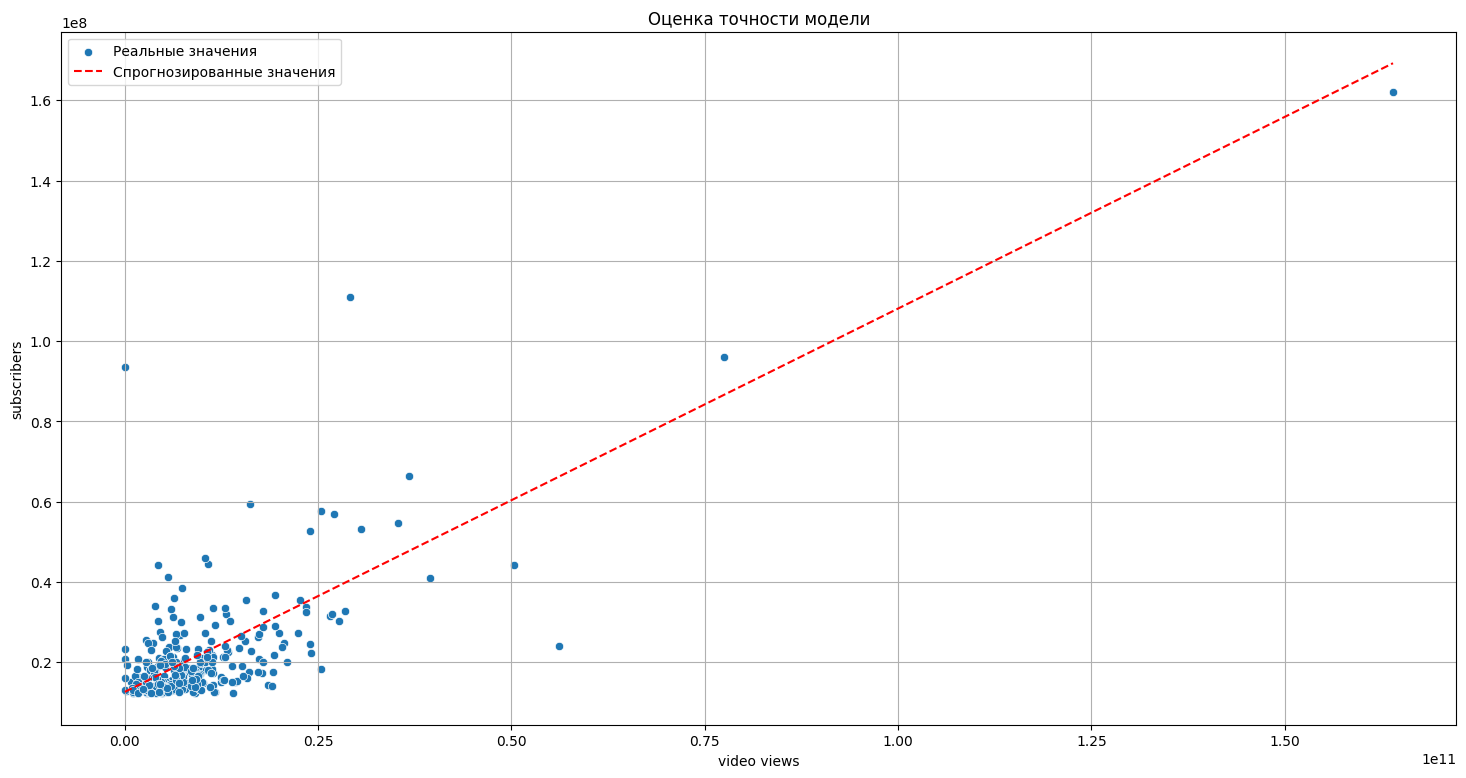

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data_cut['video views'].values.reshape(-1, 1)
                                                    , data_cut['subscribers'], test_size=0.3, random_state=5)

# Модель на неотфильтрованных данных
model = LinearRegression()
model.fit(X_train, y_train)

# Модель на неотфильтрованных данных
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказание на тестовых данных
y_pred = model.predict(X_test)

# Сохранение десяти метрик в переменной r2
r2_unfiltered = cross_val_score(model,
                      X_test,
                      y_test,
                      scoring='r2',
                      cv=10)

# Получение среднего значения для оценки качества модели
print('r2 для модели построенной на неотфильтрованных очищенных данных = ', r2_unfiltered.mean())

# Визуализация адекватности модели
plt.figure(figsize=(18, 9))
sns.scatterplot(x=X_test[:, 0] , y=y_test, label='Реальные значения')
sns.lineplot(x=X_test[:, 0] , y=y_pred, label='Спрогнозированные значения', color='red', linestyle='--')
plt.xlabel('video views')
plt.grid(True)
plt.legend()
plt.title('Оценка точности модели')
plt.show()

## Выбор лучшей модели

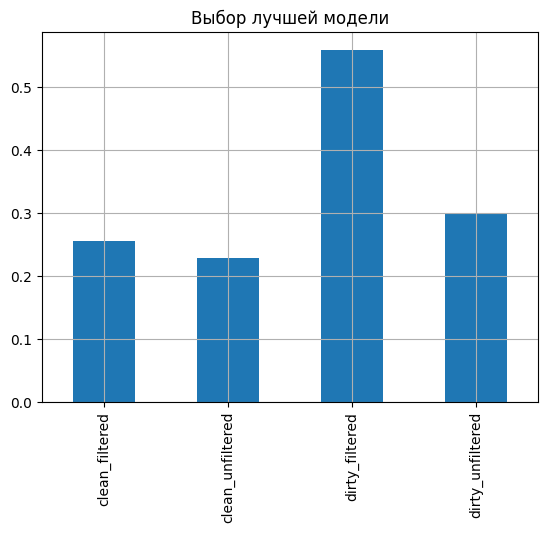

In [ ]:
r2_df = pd.DataFrame(
    {
        'clean_filtered': r2_clean_filter,
        'clean_unfiltered': r2_clean_unfiltered,
        'dirty_filtered': r2_filtered,
        'dirty_unfiltered': r2_unfiltered
    }
)

r2_df.median().plot(kind='bar')
plt.title('Выбор лучшей модели')
plt.grid(True)
plt.show()

Вывод: лучшая - модель построенная на сырых отфильтрованных данных

*В зависмости от разбиения r2 может меняться, но модель построенная на сырых отфильтрованных данных, практически всегда побеждает

# Задание 3. Классификация

1. Определите две самые популярные категории канала и отфильтруйте по ним набор данных.
2. В качестве признаков используйте следующие столбцы: [‘video views’, ‘subscribers’, ‘uploads’]
3. Снова отфильтруйте данные - уберите те строки, где кол-во просмотров равно нулю.
4. Для целевой переменной используйте столбец'category'. Значения по нему закодируйте с помощью LabelEncoder.
5. Разделите выборку на тестовую и тренировочную, укажите random_state=13.`
6. Постройте модель логистической регрессии.
7. Рассчитайте точность модели на тестовой выборке.
8. Изменится ли точность модели, если в качестве признаков выбрать другие столбцы?




In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
data.groupby(by='category')[['video views', 'subscribers']].sum().sort_values(by=['video views', 'subscribers'], ascending=[False, False]).head(2)

,video views,subscribers
category,,
Music,3.121478e+12,5195000000
Entertainment,2.527739e+12,5158200000


In [ ]:
features = ['video views', 'subscribers', 'uploads', 'category', 'lowest_yearly_earnings', 'created_year']

data_cut_1 = data.loc[data['category'].isin(['Music', 'Entertainment']), features].dropna()
data_cut_1 = data_cut_1.loc[data_cut_1['video views'] > 0]

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Применение к данным
data_cut_1['target'] = encoder.fit_transform(data_cut_1['category'])
data_cut_1.groupby(by='category').count()

,video views,subscribers,uploads,lowest_yearly_earnings,created_year,target
category,,,,,,
Entertainment,240,240,240,240,240,240
Music,200,200,200,200,200,200


Есть небольшой дисбаланс классов, нужно это учесть



In [ ]:
# Определяем целевые и нецелевые признаки
inpependent_feature = ['video views', 'subscribers', 'uploads']
target_feature = ['target']

X = data_cut_1[inpependent_feature]
y = data_cut_1[target_feature]

# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=5)

# Создаем и обучаем модель
log_model = LogisticRegression(random_state=5, class_weight='balanced')

log_model.fit(X_train, y_train)

prediction = log_model.predict(X_test)

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.82      0.65      0.73        72
           1       0.67      0.83      0.74        60

    accuracy                           0.73       132
   macro avg       0.75      0.74      0.73       132
weighted avg       0.75      0.73      0.73       132



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


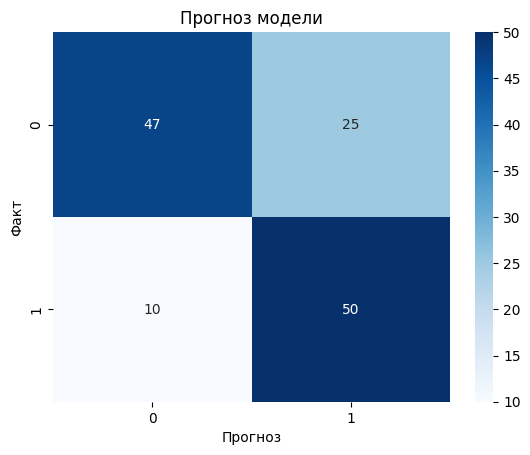

In [ ]:
cm = confusion_matrix(y_test, prediction)
sns.heatmap(cm, annot=True, fmt='', cmap='Blues')
plt.xlabel('Прогноз')
plt.ylabel('Факт')
plt.title('Прогноз модели')
plt.show()

Добавим еще 2 признака в модель, которые имеют высокую корреляцию с целевой переменной: created_year, lowest_yearly_earnings

In [ ]:
extra_feature  = ['lowest_yearly_earnings', 'created_year']

In [ ]:
# Определяем целевые и нецелевые признаки
inpependent_feature = ['video views', 'subscribers', 'uploads']
target_feature = ['target']

X = data_cut_1[inpependent_feature + extra_feature]
y = data_cut_1[target_feature]

# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=5)

# Создаем и обучаем модель
log_model = LogisticRegression(random_state=5, class_weight='balanced')

log_model.fit(X_train, y_train)

prediction = log_model.predict(X_test)

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.79      0.74      0.76        72
           1       0.71      0.77      0.74        60

    accuracy                           0.75       132
   macro avg       0.75      0.75      0.75       132
weighted avg       0.75      0.75      0.75       132



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


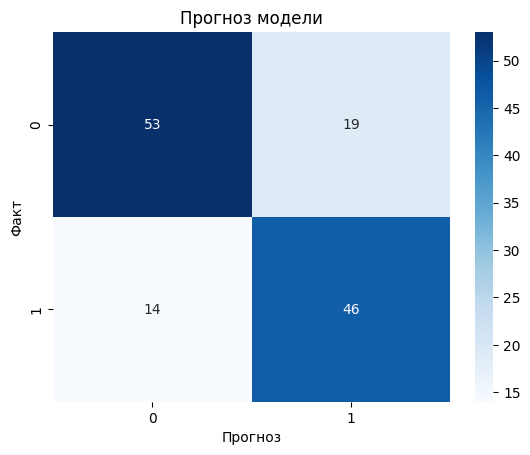

In [ ]:
cm = confusion_matrix(y_test, prediction)
sns.heatmap(cm, annot=True, fmt='', cmap='Blues')
plt.xlabel('Прогноз')
plt.ylabel('Факт')
plt.title('Прогноз модели')
plt.show()

**Вывод**: модель после добавления новых признаков улучшилась
